## -> Student Score Prediction Using Simple Linear Regression

## - Objective

Build a Simple Linear Regression model to predict a student's score based on the number of hours studied.

In [1]:
# Importing libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt

## Data Preparation

In [2]:
# Load the student score dataset
data = pd.read_csv('../datasets/Regression/score.csv')

# Display the first five rows
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [3]:
# Check the number of rows and columns
data.shape

(25, 2)

In [4]:
# Check column names, data types and missing values
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [5]:
# Select Hours as the input feature.
# Double brackets keep X as a 2D DataFrame.
X = data[['Hours']]

# Select Scores as the target we want to predict.
# A single bracket keeps y as a 1D Series.
y = data['Scores']

### Verify X and y Shapes


In [6]:
# Check that X is 2D and y is 1D before training

print("x.shape: ", X.shape)
print("y.shape: ", y.shape)

x.shape:  (25, 1)
y.shape:  (25,)


## Train-Test Split

In [7]:
# Split the data:
# 80% is used for training and 20% for testing.
# 'random_state=42' ensures that we get the same data split every time the notebook runs. 

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Model Training

In [8]:
# Create the Simple Linear Regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

## Prediction

In [9]:
# Train the model using training inputs and their corrects answers

model.fit(X_train, y_train)  # Learn from training data

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.68]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.827
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## Prediction

In [10]:
# Predict scores for the unseen test inputs

y_pred = model.predict(X_test)   # Predict unseen inputs
y_pred

array([83.18814104, 27.03208774, 27.03208774, 69.63323162, 59.95115347])

In [11]:
# Compare the actual test scores with the predicted scores

from sklearn.metrics import r2_score 
score = r2_score(y_test,y_pred)       # Compare actual and predicted answers
score

0.9678055545167994

In [12]:
results = pd.DataFrame({
    'Actual Score': y_test,
    'Predicted Score' : y_pred
})

results

,Actual Score,Predicted Score
8,81,83.188141
16,30,27.032088
0,21,27.032088
23,76,69.633232
11,62,59.951153


## Visualization

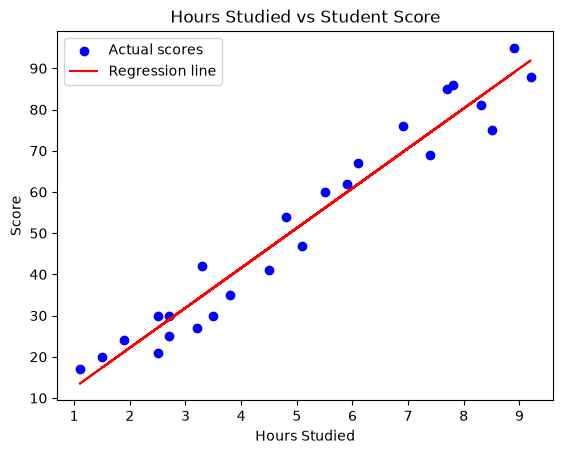

In [13]:
plt.scatter(X, y, color='blue', label='Actual scores')
plt.plot(X, model.predict(X), color='red', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Hours Studied vs Student Score')
plt.legend()
plt.show()

## Conclusion

The model achieved an R² score of approximately 0.97 on the test data. This indicates a strong positive linear relationship between hours studied and student scores. However, the dataset contains only 25 observations, so a larger dataset would be needed for a more reliable evaluation.